# Fase 5 — CLTV: Customer Lifetime Value

**Proyecto Final — Gestión de Datos (UAX) · 3º Ingeniería Matemática**  
**Paleta:** Ámbar/Naranja — cada fase del proyecto usa una paleta distinta.

Este notebook calcula el **Customer Lifetime Value (CLTV)** de los 5.750 clientes
a partir del Data Warehouse construido en la Fase 4. Se añaden dos métricas adicionales
de alto valor analítico: el **Churn Proxy** y la **Segmentación RFM**.

```
DWH (dwh.fact_sales + dwh.dim_customer)  ──▶  CLTV + Churn + RFM  ──▶  cltv_resultados.csv
```

---

## Formula CLTV

$$\text{CLTV} = \text{Ingresos}_t \times \text{Margen}_t \times \text{Frecuencia}_t \times R_t$$

| Componente | Descripcion | Unidad |
|------------|-------------|--------|
| $\text{Ingresos}_t$ | Ingresos netos totales del cliente | EUR |
| $\text{Margen}_t$ | Margen total / ingresos netos | Ratio 0-1 |
| $\text{Frecuencia}_t$ | Num. ventas / meses activo | ventas/mes |
| $R_t$ | Antiguedad del cliente | meses |

> **Nota:** la variable `cltv` exportada sigue literalmente la formula del enunciado.
> `margen_total`, recencia, ticket medio, churn y RFM se conservan como metricas complementarias.

---

## Tabla de contenidos

| # | Seccion | Descripcion |
|---|---------|-------------|
| 1 | Imports, paleta y conexion | Setup inicial |
| 2 | Extraccion desde el DWH | Query SQL por cliente |
| 3 | Calculo CLTV | Componentes + formula |
| 4 | Segmentacion por CLTV | Alto / Medio / Bajo (P25-P75) |
| 5 | Metrica adicional 1: Churn Proxy | Clientes en riesgo de abandono |
| 6 | Metrica adicional 2: Tasa de devolucion | Satisfaccion por cliente |
| 7 | Segmentacion RFM | Recency * Frequency * Monetary |
| 8 | Visualizaciones CLTV | Distribucion, top 20, segmentos |
| 9 | Visualizaciones RFM | Heatmap, segmentos |
| 10 | Exportar resultados | cltv_resultados.csv (5.750 filas) |

---
## 1. Imports, paleta y conexion

Conexion al DWH: OK
  dwh.fact_sales:   42,555 filas
  dwh.dim_customer: 5,750 filas


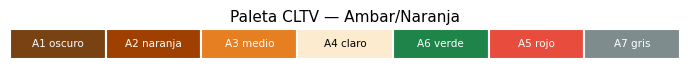

In [1]:
import os
import warnings
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import sqlalchemy as sa
from sqlalchemy import text
from IPython.display import display

warnings.filterwarnings('ignore')
os.makedirs('graficos', exist_ok=True)

# ── PALETA CLTV (AMBAR / NARANJA) ─────────────────────────────────────────────
A1 = '#784212'   # marron-naranja oscuro — principal
A2 = '#A04000'   # naranja oscuro        — secundario
A3 = '#E67E22'   # naranja medio         — tercer nivel
A4 = '#FDEBD0'   # naranja muy claro     — cuarto nivel
A5 = '#E74C3C'   # rojo                  — riesgo / bajo valor
A6 = '#1E8449'   # verde                 — positivo / alto valor
A7 = '#7F8C8D'   # gris                  — neutro
PALETTE_CLTV = [A1, A2, A3, A4, A6, A5]
SEQ_CMAP     = 'Oranges'

COLOR_ALTO   = A6   # verde  — alto valor
COLOR_MEDIO  = A3   # naranja — valor medio
COLOR_BAJO   = A5   # rojo   — bajo valor

plt.rcParams.update({
    'figure.facecolor':  'white',
    'axes.facecolor':    '#FFFBF0',
    'axes.spines.top':   False,
    'axes.spines.right': False,
    'axes.titlesize':    13,
    'axes.labelsize':    11,
    'xtick.labelsize':   10,
    'ytick.labelsize':   10,
    'font.family':       'DejaVu Sans',
})

# ── CONEXION AL DWH ───────────────────────────────────────────────────────────
HOST, PORT, DB_NAME, USER, PASSWORD = 'localhost', 5432, 'Proyecto_final', 'admin', 'admin'
engine = sa.create_engine(f'postgresql+psycopg2://{USER}:{PASSWORD}@{HOST}:{PORT}/{DB_NAME}')

with engine.connect() as conn:
    n_fact = conn.execute(text('SELECT COUNT(*) FROM dwh.fact_sales')).scalar()
    n_cust = conn.execute(text('SELECT COUNT(*) FROM dwh.dim_customer')).scalar()
    print(f'Conexion al DWH: OK')
    print(f'  dwh.fact_sales:   {n_fact:,} filas')
    print(f'  dwh.dim_customer: {n_cust:,} filas')

# Barra de paleta
fig, ax = plt.subplots(figsize=(7, 0.8))
colors = [A1, A2, A3, A4, A6, A5, A7]
labels = ['A1 oscuro', 'A2 naranja', 'A3 medio', 'A4 claro', 'A6 verde', 'A5 rojo', 'A7 gris']
for i, (c, l) in enumerate(zip(colors, labels)):
    ax.barh(0, 1, left=i, color=c, edgecolor='white', linewidth=1.5)
    ax.text(i + 0.5, 0, l, ha='center', va='center', fontsize=7.5,
            color='white' if i < 3 else ('black' if i == 3 else 'white'))
ax.set_xlim(0, 7)
ax.axis('off')
ax.set_title('Paleta CLTV — Ambar/Naranja', fontsize=11, pad=4)
plt.tight_layout()
plt.savefig('graficos/cltv_00_paleta.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()

---
## 2. Extraccion desde el DWH

Consultamos el DWH para obtener todas las metricas necesarias por cliente en una sola query.
Agrupamos `fact_sales` a nivel de cliente y hacemos JOIN con `dim_customer`
para obtener la antiguedad (`customer_age_days`) y las fechas de primera y ultima compra.

In [2]:
query = """
SELECT
    f.customer_id,
    c.full_name,
    c.first_purchase_date,
    c.last_purchase_date,
    c.customer_age_days,
    SUM(f.net_revenue)                              AS ingresos_t,
    SUM(f.margin)                                   AS margen_total,
    COUNT(DISTINCT f.sale_id)                       AS num_ventas,
    COUNT(f.sale_item_id)                           AS num_lineas,
    SUM(CASE WHEN f.has_return THEN 1 ELSE 0 END)   AS num_devoluciones
FROM dwh.fact_sales f
JOIN dwh.dim_customer c USING (customer_id)
GROUP BY
    f.customer_id, c.full_name, c.first_purchase_date,
    c.last_purchase_date, c.customer_age_days
ORDER BY f.customer_id
"""

with engine.connect() as conn:
    df = pd.read_sql(text(query), conn)

df['last_purchase_date']  = pd.to_datetime(df['last_purchase_date'])
df['first_purchase_date'] = pd.to_datetime(df['first_purchase_date'])

print(f'Clientes extraidos: {len(df):,}')
print(f'Columnas: {list(df.columns)}')
print(f'\nEstadisticas base:')
print(df[['ingresos_t','margen_total','num_ventas','customer_age_days']].describe().round(2).to_string())
df.head(3)

Clientes extraidos: 5,750
Columnas: ['customer_id', 'full_name', 'first_purchase_date', 'last_purchase_date', 'customer_age_days', 'ingresos_t', 'margen_total', 'num_ventas', 'num_lineas', 'num_devoluciones']

Estadisticas base:
       ingresos_t  margen_total  num_ventas  customer_age_days
count     5750.00       5750.00     5750.00            5750.00
mean      1683.25        661.43        3.48            1993.61
std       4089.97       1606.35        6.59              57.40
min         19.99        -80.00        1.00            1210.00
25%         79.80         31.92        1.00            1998.00
50%        149.90         59.96        1.00            1998.00
75%        299.99        120.00        1.00            1998.00
max      24922.00       9825.40       34.00            2183.00


,customer_id,full_name,first_purchase_date,last_purchase_date,customer_age_days,ingresos_t,margen_total,num_ventas,num_lineas,num_devoluciones
0,1,Marta Ruiz García,2020-06-29,2025-10-01,1920,11732.55,4688.48,22,57,2
1,2,Alejandro López López,2020-03-02,2025-10-30,2068,12744.26,5098.08,24,64,6
2,3,Alejandro López Álvarez,2020-08-17,2025-11-07,1908,19862.51,7897.44,24,72,5


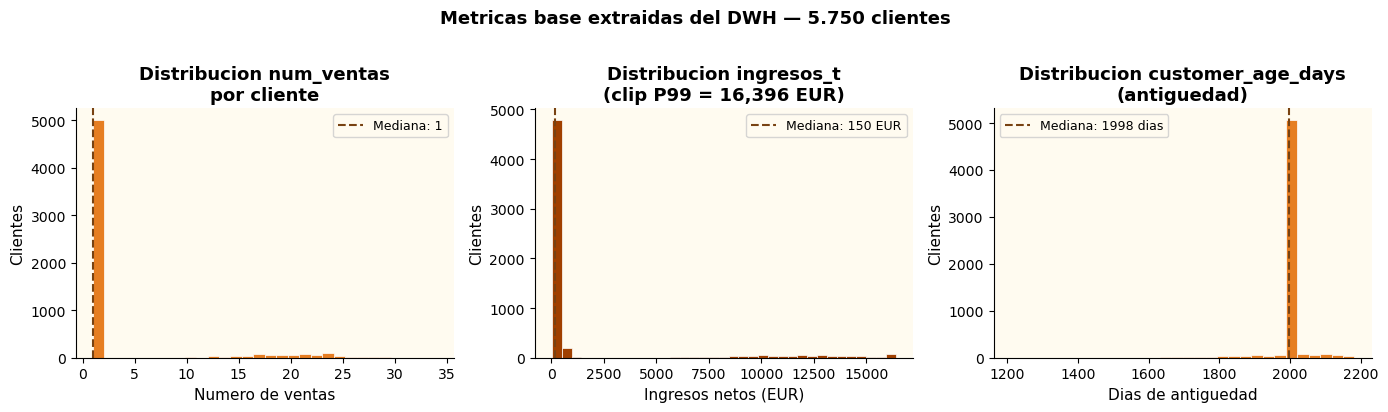

Guardado: graficos/cltv_02_base.png


In [3]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# ── Plot 1: distribucion num_ventas ────────────────────────────────────────
axes[0].hist(df['num_ventas'], bins=30, color=A3, edgecolor='white', linewidth=0.5)
axes[0].axvline(df['num_ventas'].median(), color=A1, linestyle='--', linewidth=1.5,
                label=f'Mediana: {df["num_ventas"].median():.0f}')
axes[0].set_title('Distribucion num_ventas\npor cliente', fontweight='bold')
axes[0].set_xlabel('Numero de ventas')
axes[0].set_ylabel('Clientes')
axes[0].legend(fontsize=9)

# ── Plot 2: distribucion ingresos_t ───────────────────────────────────────
clip_ing = df['ingresos_t'].quantile(0.99)
axes[1].hist(df['ingresos_t'].clip(upper=clip_ing), bins=35,
             color=A2, edgecolor='white', linewidth=0.5)
axes[1].axvline(df['ingresos_t'].median(), color=A1, linestyle='--', linewidth=1.5,
                label=f'Mediana: {df["ingresos_t"].median():,.0f} EUR')
axes[1].set_title(f'Distribucion ingresos_t\n(clip P99 = {clip_ing:,.0f} EUR)', fontweight='bold')
axes[1].set_xlabel('Ingresos netos (EUR)')
axes[1].set_ylabel('Clientes')
axes[1].legend(fontsize=9)

# ── Plot 3: distribucion customer_age_days ────────────────────────────────
axes[2].hist(df['customer_age_days'], bins=30, color=A3, edgecolor='white', linewidth=0.5)
axes[2].axvline(df['customer_age_days'].median(), color=A1, linestyle='--', linewidth=1.5,
                label=f'Mediana: {df["customer_age_days"].median():.0f} dias')
axes[2].set_title('Distribucion customer_age_days\n(antiguedad)', fontweight='bold')
axes[2].set_xlabel('Dias de antiguedad')
axes[2].set_ylabel('Clientes')
axes[2].legend(fontsize=9)

fig.suptitle('Metricas base extraidas del DWH — 5.750 clientes',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficos/cltv_02_base.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Guardado: graficos/cltv_02_base.png')

---
## 3. Calculo del CLTV

Calculamos los componentes de valor del cliente y el CLTV segun la formula del enunciado.

| Variable | Calculo |
|----------|---------|
| `r_t` | `customer_age_days / 30` — antiguedad en meses |
| `margen_t` | `margen_total / ingresos_t` — ratio de margen (0-1) |
| `frecuencia_t` | `num_ventas / r_t` — compras por mes |
| `ticket_medio` | `ingresos_t / num_ventas` — gasto medio por compra |
| `cltv` | `ingresos_t * margen_t * frecuencia_t * r_t` |

> El `cltv` de esta fase usa la formula indicada en el enunciado.
> Las variables `ticket_medio`, `churn_proxy`, devoluciones y RFM
> se usan como metricas complementarias de comportamiento.

In [4]:
# ── Componentes ───────────────────────────────────────────────────────────

n_margen_null = df['margen_total'].isnull().sum()
if n_margen_null > 0:
    print(f'AVISO: {n_margen_null} clientes tienen margen_total NULL; se imputa 0 para mantener la exportacion.')
df['margen_total'] = df['margen_total'].fillna(0)

# r_t: mínimo 1 mes para evitar valores negativos o cercanos a 0
# (clientes con created_at futuro pueden tener customer_age_days negativo)
df['r_t'] = (df['customer_age_days'] / 30.0).clip(lower=1.0)

# Diagnóstico: cuántos clientes tenían r_t problemático antes del clip
n_rt_negativos = (df['customer_age_days'] < 0).sum()
n_rt_menores1  = (df['customer_age_days'] / 30.0 < 1.0).sum()
print(f'Clientes con customer_age_days < 0:      {n_rt_negativos}')
print(f'Clientes con r_t < 1 mes (antes clip):   {n_rt_menores1}')
print(f'  → r_t corregido a mínimo 1.0 mes para todos ellos')

# margen_t: ratio 0-1, protegido contra ingresos_t = 0
df['margen_t'] = (
    df['margen_total'] / df['ingresos_t'].replace(0, np.nan)
).fillna(0).clip(0, 1)

df['frecuencia_t'] = df['num_ventas'] / df['r_t']   # r_t >= 1.0 → sin riesgo de división por 0
df['ticket_medio'] = df['ingresos_t'] / df['num_ventas']

# ── CLTV segun enunciado ────────────────────────────────────────────────
# CLTV = Ingresos_t * Margen_t * Frecuencia_t * R_t
df['cltv'] = (
    df['ingresos_t'] * df['margen_t'] * df['frecuencia_t'] * df['r_t']
).clip(lower=0).round(2)

# Diagnóstico
n_null     = df['cltv'].isnull().sum()
n_cero     = (df['cltv'] == 0).sum()
n_negativos = (df['cltv'] < 0).sum()
print(f'\nNULLs en cltv:      {n_null}   (debe ser 0)')
print(f'CLTV negativos:     {n_negativos}  (debe ser 0)')
print(f'Clientes CLTV = 0:  {n_cero}')
print()

print('Estadisticas CLTV:')
stats = df['cltv'].describe(percentiles=[.10, .25, .50, .75, .90, .95])
for k, v in stats.items():
    print(f'  {k:<8} {v:>14,.2f}')

print(f'\nComponentes medios por cliente:')
print(f'  r_t (meses activo):      {df["r_t"].mean():>10.1f}')
print(f'  margen_t (ratio):        {df["margen_t"].mean():>10.4f}')
print(f'  frecuencia_t (v/mes):    {df["frecuencia_t"].mean():>10.4f}')
print(f'  ticket_medio (EUR):      {df["ticket_medio"].mean():>10.2f}')
print(f'  CLTV medio (EUR):        {df["cltv"].mean():>10,.2f}')

Clientes con customer_age_days < 0:      0
Clientes con r_t < 1 mes (antes clip):   0
  → r_t corregido a mínimo 1.0 mes para todos ellos

NULLs en cltv:      0   (debe ser 0)
CLTV negativos:     0  (debe ser 0)
Clientes CLTV = 0:  7

Estadisticas CLTV:
  count          5,750.00
  mean          12,712.47
  std           36,471.67
  min                0.00
  10%               15.96
  25%               31.92
  50%               59.96
  75%              120.00
  90%           62,829.01
  95%          103,750.39
  max          324,238.20

Componentes medios por cliente:
  r_t (meses activo):            66.5
  margen_t (ratio):            0.3985
  frecuencia_t (v/mes):        0.0530
  ticket_medio (EUR):          221.09
  CLTV medio (EUR):         12,712.47


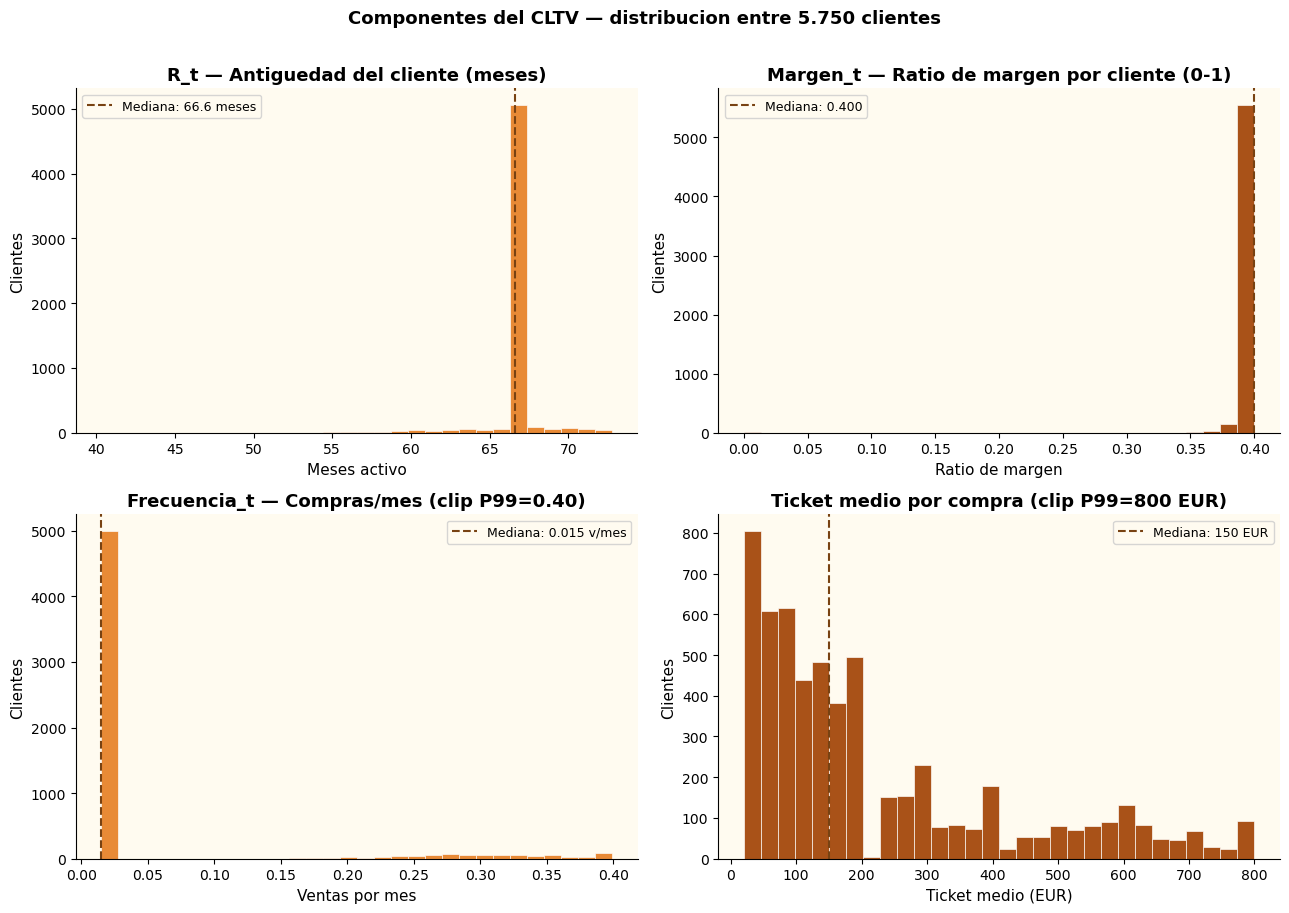

Guardado: graficos/cltv_03_componentes.png


In [5]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9))

# ── Plot 1: r_t ───────────────────────────────────────────────────────────
axes[0,0].hist(df['r_t'], bins=30, color=A3, edgecolor='white', linewidth=0.5, alpha=0.9)
axes[0,0].axvline(df['r_t'].median(), color=A1, linestyle='--', linewidth=1.5,
                   label=f'Mediana: {df["r_t"].median():.1f} meses')
axes[0,0].set_title('R_t — Antiguedad del cliente (meses)', fontweight='bold')
axes[0,0].set_xlabel('Meses activo')
axes[0,0].set_ylabel('Clientes')
axes[0,0].legend(fontsize=9)

# ── Plot 2: margen_t ──────────────────────────────────────────────────────
axes[0,1].hist(df['margen_t'], bins=30, color=A2, edgecolor='white', linewidth=0.5, alpha=0.9)
axes[0,1].axvline(df['margen_t'].median(), color=A1, linestyle='--', linewidth=1.5,
                   label=f'Mediana: {df["margen_t"].median():.3f}')
axes[0,1].set_title('Margen_t — Ratio de margen por cliente (0-1)', fontweight='bold')
axes[0,1].set_xlabel('Ratio de margen')
axes[0,1].set_ylabel('Clientes')
axes[0,1].legend(fontsize=9)

# ── Plot 3: frecuencia_t ──────────────────────────────────────────────────
clip_f = df['frecuencia_t'].quantile(0.99)
axes[1,0].hist(df['frecuencia_t'].clip(upper=clip_f), bins=30,
               color=A3, edgecolor='white', linewidth=0.5, alpha=0.9)
axes[1,0].axvline(df['frecuencia_t'].median(), color=A1, linestyle='--', linewidth=1.5,
                   label=f'Mediana: {df["frecuencia_t"].median():.3f} v/mes')
axes[1,0].set_title(f'Frecuencia_t — Compras/mes (clip P99={clip_f:.2f})', fontweight='bold')
axes[1,0].set_xlabel('Ventas por mes')
axes[1,0].set_ylabel('Clientes')
axes[1,0].legend(fontsize=9)

# ── Plot 4: ticket_medio ──────────────────────────────────────────────────
clip_t = df['ticket_medio'].quantile(0.99)
axes[1,1].hist(df['ticket_medio'].clip(upper=clip_t), bins=30,
               color=A2, edgecolor='white', linewidth=0.5, alpha=0.9)
axes[1,1].axvline(df['ticket_medio'].median(), color=A1, linestyle='--', linewidth=1.5,
                   label=f'Mediana: {df["ticket_medio"].median():.0f} EUR')
axes[1,1].set_title(f'Ticket medio por compra (clip P99={clip_t:.0f} EUR)', fontweight='bold')
axes[1,1].set_xlabel('Ticket medio (EUR)')
axes[1,1].set_ylabel('Clientes')
axes[1,1].legend(fontsize=9)

fig.suptitle('Componentes del CLTV — distribucion entre 5.750 clientes',
             fontsize=13, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('graficos/cltv_03_componentes.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Guardado: graficos/cltv_03_componentes.png')

---
## 4. Segmentacion por CLTV

Segmentamos los clientes en tres grupos usando los percentiles P25 y P75 del CLTV:

| Segmento | Criterio | Esperado |
|----------|----------|----------|
| **Alto** | CLTV > P75 | ~1.437 clientes (25%) |
| **Medio** | P25 <= CLTV <= P75 | ~2.875 clientes (50%) |
| **Bajo** | CLTV < P25 | ~1.437 clientes (25%) |

> Los clientes de segmento **Alto** suelen concentrar >90% de los ingresos totales.

In [6]:
p25 = df['cltv'].quantile(0.25)
p75 = df['cltv'].quantile(0.75)

def segmento_cltv(v):
    if v > p75:
        return 'Alto'
    elif v >= p25:
        return 'Medio'
    else:
        return 'Bajo'

df['segmento_cltv'] = df['cltv'].apply(segmento_cltv)

print(f'Percentiles CLTV:  P25={p25:,.2f} EUR | P75={p75:,.2f} EUR')

resumen_seg = df.groupby('segmento_cltv').agg(
    n_clientes  = ('customer_id', 'count'),
    cltv_medio  = ('cltv', 'mean'),
    ingresos    = ('ingresos_t', 'sum'),
).reindex(['Alto','Medio','Bajo'])
total_ing = df['ingresos_t'].sum()
resumen_seg['pct_ingresos'] = (resumen_seg['ingresos'] / total_ing * 100).round(1)
resumen_seg['pct_clientes'] = (resumen_seg['n_clientes'] / len(df) * 100).round(1)

print('\nResumen por segmento CLTV:')
print(resumen_seg[['n_clientes','pct_clientes','cltv_medio','ingresos','pct_ingresos']].to_string())

Percentiles CLTV:  P25=31.92 EUR | P75=120.00 EUR

Resumen por segmento CLTV:
               n_clientes  pct_clientes    cltv_medio    ingresos  pct_ingresos
segmento_cltv                                                                  
Alto                 1386          24.1  52588.033651  9154330.13          94.6
Medio                2931          51.0     63.426339   464728.36           4.8
Bajo                 1433          24.9     16.589812    59620.18           0.6


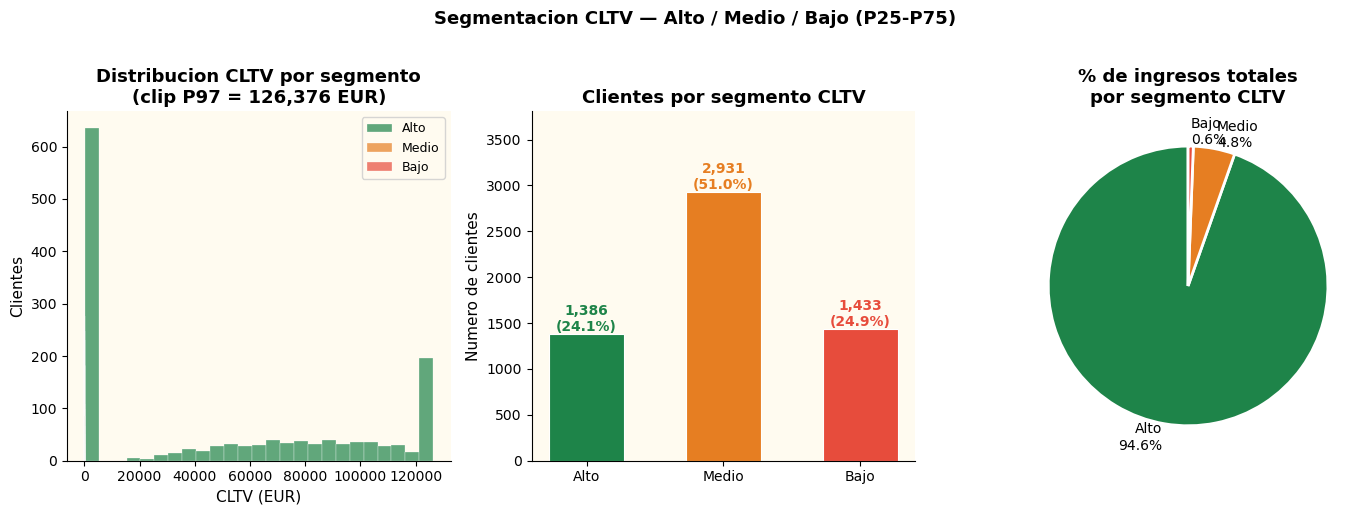

Guardado: graficos/cltv_04_segmentos.png


In [7]:
colores_seg = {'Alto': COLOR_ALTO, 'Medio': COLOR_MEDIO, 'Bajo': COLOR_BAJO}
orden_seg   = ['Alto', 'Medio', 'Bajo']

fig, axes = plt.subplots(1, 3, figsize=(14, 5))

# ── Plot 1: histograma CLTV coloreado por segmento ────────────────────────
clip_cltv = df['cltv'].quantile(0.97)
for seg, color in colores_seg.items():
    subset = df.loc[df['segmento_cltv'] == seg, 'cltv'].clip(upper=clip_cltv)
    axes[0].hist(subset, bins=25, color=color, alpha=0.7, label=seg,
                 edgecolor='white', linewidth=0.3)
axes[0].set_title(f'Distribucion CLTV por segmento\n(clip P97 = {clip_cltv:,.0f} EUR)',
                  fontweight='bold')
axes[0].set_xlabel('CLTV (EUR)')
axes[0].set_ylabel('Clientes')
axes[0].legend(fontsize=9)

# ── Plot 2: clientes por segmento ─────────────────────────────────────────
n_seg   = resumen_seg['n_clientes'].reindex(orden_seg)
pct_seg = resumen_seg['pct_clientes'].reindex(orden_seg)
bars2 = axes[1].bar(orden_seg, n_seg.values,
                    color=[colores_seg[s] for s in orden_seg],
                    edgecolor='white', linewidth=0.8, width=0.55)
for bar, n, pct in zip(bars2, n_seg.values, pct_seg.values):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                 f'{n:,}\n({pct:.1f}%)', ha='center', fontsize=10,
                 fontweight='bold', color=bar.get_facecolor())
axes[1].set_title('Clientes por segmento CLTV', fontweight='bold')
axes[1].set_ylabel('Numero de clientes')
axes[1].set_ylim(0, n_seg.max() * 1.3)

# ── Plot 3: % ingresos por segmento (pie) ────────────────────────────────
pct_ing = resumen_seg['pct_ingresos'].reindex(orden_seg)
axes[2].pie(
    pct_ing.values,
    labels=[f'{s}\n{p:.1f}%' for s, p in zip(orden_seg, pct_ing.values)],
    colors=[colores_seg[s] for s in orden_seg],
    startangle=90,
    wedgeprops={'edgecolor': 'white', 'linewidth': 2},
)
axes[2].set_title('% de ingresos totales\npor segmento CLTV', fontweight='bold')

fig.suptitle('Segmentacion CLTV — Alto / Medio / Bajo (P25-P75)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficos/cltv_04_segmentos.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Guardado: graficos/cltv_04_segmentos.png')

---
## 5. Metrica adicional 1 — Churn Proxy

El **churn proxy** es un indicador de riesgo de abandono basado en la inactividad reciente.
Un cliente se considera **en riesgo** si no ha realizado ninguna compra en los ultimos 180 dias
respecto a la fecha maxima observada en el dataset.

| Metrica | Descripcion |
|---------|-------------|
| `dias_sin_compra` | Dias entre `last_purchase_date` y la fecha de referencia |
| `churn_proxy` | `True` si `dias_sin_compra > 180` |

> **Por que 180 dias:** medio ano sin compra en un contexto de productos de salud
> (compra media cada 1-2 meses) es una senal de abandono relevante para acciones de CRM.

In [8]:
FECHA_REF = df['last_purchase_date'].max().normalize()

df['dias_sin_compra'] = (FECHA_REF - df['last_purchase_date']).dt.days
df['churn_proxy']     = df['dias_sin_compra'] > 180

n_riesgo   = df['churn_proxy'].sum()
n_activo   = (~df['churn_proxy']).sum()
pct_riesgo = n_riesgo / len(df) * 100

print(f'Fecha de referencia: {FECHA_REF.date()}')
print(f'Clientes en riesgo (>180 dias): {n_riesgo:,} ({pct_riesgo:.1f}%)')
print(f'Clientes activos   (<=180 dias): {n_activo:,} ({100-pct_riesgo:.1f}%)')

# Clientes criticos: Alto CLTV + en riesgo
criticos = df[(df['churn_proxy']) & (df['segmento_cltv'] == 'Alto')]
print(f'\nClientes ALTO CLTV en riesgo de churn: {len(criticos):,}')
print(f'  Ingresos historicos en riesgo: {criticos["ingresos_t"].sum():,.0f} EUR')
print(f'  Representan el {criticos["ingresos_t"].sum() / total_ing * 100:.1f}% de los ingresos totales')

Fecha de referencia: 2025-12-30
Clientes en riesgo (>180 dias): 3,678 (64.0%)
Clientes activos   (<=180 dias): 2,072 (36.0%)

Clientes ALTO CLTV en riesgo de churn: 606
  Ingresos historicos en riesgo: 1,893,935 EUR
  Representan el 19.6% de los ingresos totales


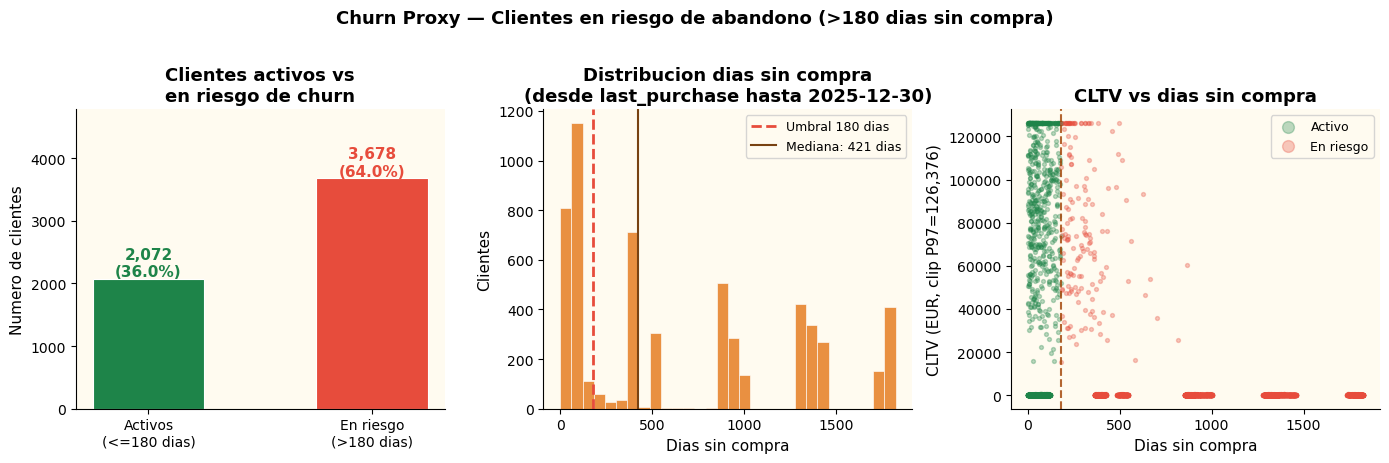

Guardado: graficos/cltv_05_churn.png


In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4.5))

# ── Plot 1: activos vs en riesgo ──────────────────────────────────────────
vals_churn = [n_activo, n_riesgo]
labs_churn = ['Activos\n(<=180 dias)', 'En riesgo\n(>180 dias)']
cols_churn = [A6, A5]
bars1 = axes[0].bar(labs_churn, vals_churn, color=cols_churn,
                    edgecolor='white', linewidth=0.8, width=0.5)
for bar, val, pct in zip(bars1, vals_churn, [100-pct_riesgo, pct_riesgo]):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 40,
                 f'{val:,}\n({pct:.1f}%)', ha='center', fontsize=11,
                 fontweight='bold', color=bar.get_facecolor())
axes[0].set_title('Clientes activos vs\nen riesgo de churn', fontweight='bold')
axes[0].set_ylabel('Numero de clientes')
axes[0].set_ylim(0, max(vals_churn) * 1.3)

# ── Plot 2: histograma dias_sin_compra ────────────────────────────────────
axes[1].hist(df['dias_sin_compra'], bins=30, color=A3,
             edgecolor='white', linewidth=0.5, alpha=0.85)
axes[1].axvline(180, color=A5, linestyle='--', linewidth=2,
                label='Umbral 180 dias')
axes[1].axvline(df['dias_sin_compra'].median(), color=A1, linestyle='-', linewidth=1.5,
                label=f'Mediana: {df["dias_sin_compra"].median():.0f} dias')
axes[1].set_title('Distribucion dias sin compra\n(desde last_purchase hasta 2025-12-30)',
                  fontweight='bold')
axes[1].set_xlabel('Dias sin compra')
axes[1].set_ylabel('Clientes')
axes[1].legend(fontsize=9)

# ── Plot 3: CLTV vs dias_sin_compra ──────────────────────────────────────
clip_c = df['cltv'].quantile(0.97)
for churn_val, color, label in [(False, A6, 'Activo'), (True, A5, 'En riesgo')]:
    sub = df[df['churn_proxy'] == churn_val]
    axes[2].scatter(sub['dias_sin_compra'], sub['cltv'].clip(upper=clip_c),
                    color=color, alpha=0.3, s=8, label=label)
axes[2].axvline(180, color=A2, linestyle='--', linewidth=1.5, alpha=0.8)
axes[2].set_title('CLTV vs dias sin compra', fontweight='bold')
axes[2].set_xlabel('Dias sin compra')
axes[2].set_ylabel(f'CLTV (EUR, clip P97={clip_c:,.0f})')
axes[2].legend(fontsize=9, markerscale=3)

fig.suptitle('Churn Proxy — Clientes en riesgo de abandono (>180 dias sin compra)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficos/cltv_05_churn.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Guardado: graficos/cltv_05_churn.png')

---
## 6. Metrica adicional 2 — Tasa de devolucion

La **tasa de devolucion** mide que fraccion de las lineas compradas por un cliente
han sido devueltas. Es un proxy de satisfaccion: tasas altas pueden indicar
problemas con expectativas, calidad percibida o errores en el pedido.

$$\text{tasa\_devolucion} = \frac{\text{num\_devoluciones}}{\text{num\_lineas}}$$

In [10]:
df['tasa_devolucion'] = (df['num_devoluciones'] / df['num_lineas']).fillna(0).round(4)

n_sin_dev = (df['num_devoluciones'] == 0).sum()
n_con_dev = (df['num_devoluciones'] > 0).sum()

print('Tasa de devolucion — estadisticas:')
print(df['tasa_devolucion'].describe(percentiles=[.25,.50,.75,.90]).round(4).to_string())
print(f'\nClientes sin ninguna devolucion: {n_sin_dev:,} ({n_sin_dev/len(df)*100:.1f}%)')
print(f'Clientes con alguna devolucion:  {n_con_dev:,} ({n_con_dev/len(df)*100:.1f}%)')

Tasa de devolucion — estadisticas:
count    5750.0000
mean        0.0828
std         0.2648
min         0.0000
25%         0.0000
50%         0.0000
75%         0.0000
90%         0.0751
max         1.0000

Clientes sin ninguna devolucion: 4,626 (80.5%)
Clientes con alguna devolucion:  1,124 (19.5%)


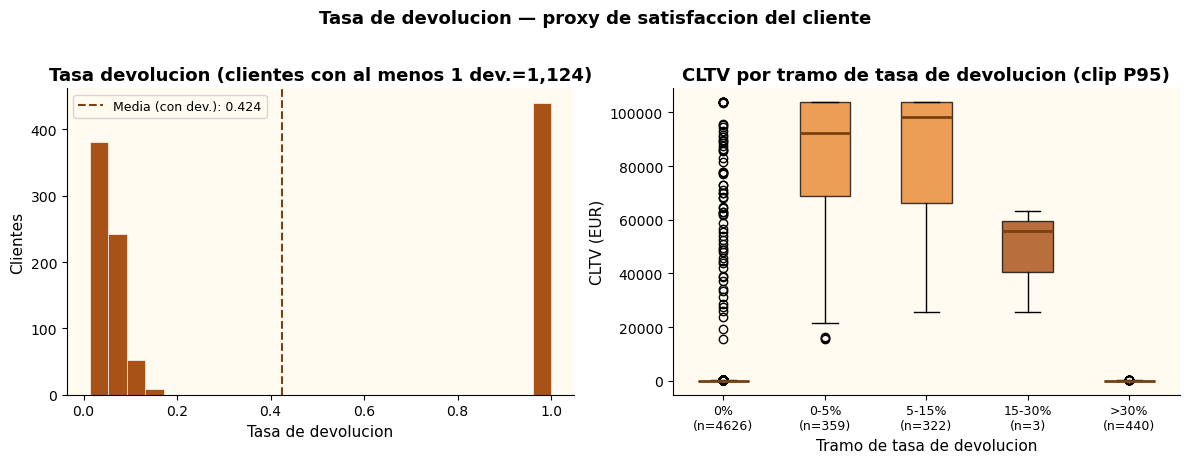

Guardado: graficos/cltv_06_devolucion.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# ── Plot 1: histograma tasa_devolucion (solo los que tienen) ─────────────
con_dev = df[df['tasa_devolucion'] > 0]['tasa_devolucion']
axes[0].hist(con_dev, bins=25, color=A2, edgecolor='white', linewidth=0.5, alpha=0.9)
axes[0].axvline(con_dev.mean(), color=A1, linestyle='--', linewidth=1.5,
                label=f'Media (con dev.): {con_dev.mean():.3f}')
axes[0].set_title(f'Tasa devolucion (clientes con al menos 1 dev.={n_con_dev:,})',
                  fontweight='bold')
axes[0].set_xlabel('Tasa de devolucion')
axes[0].set_ylabel('Clientes')
axes[0].legend(fontsize=9)

# ── Plot 2: boxplot CLTV por tramo de tasa devolucion ────────────────────
df['tramo_dev'] = pd.cut(
    df['tasa_devolucion'],
    bins=[-0.001, 0, 0.05, 0.15, 0.30, 1.01],
    labels=['0%', '0-5%', '5-15%', '15-30%', '>30%']
)
orden_dev  = ['0%', '0-5%', '5-15%', '15-30%', '>30%']
clip_cltv_dev = df['cltv'].quantile(0.95)
data_box   = [df.loc[df['tramo_dev'] == t, 'cltv'].clip(upper=clip_cltv_dev).values
              for t in orden_dev]
n_tramos   = [df[df['tramo_dev'] == t].shape[0] for t in orden_dev]
cols_dev   = [A6, A3, A3, A2, A5]

bp = axes[1].boxplot(data_box, patch_artist=True, notch=False,
                     medianprops={'color': A1, 'linewidth': 2})
for patch, color in zip(bp['boxes'], cols_dev):
    patch.set_facecolor(color)
    patch.set_alpha(0.75)
axes[1].set_xticklabels([f'{t}\n(n={n})' for t, n in zip(orden_dev, n_tramos)], fontsize=9)
axes[1].set_title('CLTV por tramo de tasa de devolucion (clip P95)',
                  fontweight='bold')
axes[1].set_xlabel('Tramo de tasa de devolucion')
axes[1].set_ylabel('CLTV (EUR)')

fig.suptitle('Tasa de devolucion — proxy de satisfaccion del cliente',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficos/cltv_06_devolucion.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Guardado: graficos/cltv_06_devolucion.png')

---
## 7. Segmentacion RFM

La segmentacion **RFM** (Recency * Frequency * Monetary) es el framework estandar
de CRM para clasificar clientes segun su comportamiento de compra.

| Dimension | Variable usada | Score alto = |
|-----------|---------------|-------------|
| **R** (Recency) | `dias_sin_compra` | Compra reciente (pocos dias) |
| **F** (Frequency) | `num_ventas` | Muchas compras |
| **M** (Monetary) | `ingresos_t` | Mucho gasto |

Cada dimension se divide en cuartiles (1-4). Para Recency, el score **se invierte**:
menos dias = mejor = score 4.

In [12]:
# R: menos dias = mejor → labels invertidos [4,3,2,1]
df['R_score'] = pd.qcut(df['dias_sin_compra'], 4, labels=[4,3,2,1],
                        duplicates='drop').astype(int)
# F: mas ventas = mejor → labels [1,2,3,4]
df['F_score'] = pd.qcut(df['num_ventas'].rank(method='first'), 4,
                        labels=[1,2,3,4]).astype(int)
# M: mas ingresos = mejor → labels [1,2,3,4]
df['M_score'] = pd.qcut(df['ingresos_t'], 4, labels=[1,2,3,4],
                        duplicates='drop').astype(int)

df['rfm_score'] = df['R_score'] + df['F_score'] + df['M_score']

print('Distribucion de scores (1=peor, 4=mejor):')
for dim in ['R_score','F_score','M_score']:
    print(f'  {dim}: {dict(df[dim].value_counts().sort_index())}')
print(f'rfm_score total (3-12): min={df["rfm_score"].min()}, '
      f'max={df["rfm_score"].max()}, media={df["rfm_score"].mean():.1f}')

Distribucion de scores (1=peor, 4=mejor):
  R_score: {1: np.int64(1438), 2: np.int64(1434), 3: np.int64(1439), 4: np.int64(1439)}
  F_score: {1: np.int64(1438), 2: np.int64(1437), 3: np.int64(1437), 4: np.int64(1438)}
  M_score: {1: np.int64(1505), 2: np.int64(1432), 3: np.int64(1427), 4: np.int64(1386)}
rfm_score total (3-12): min=3, max=12, media=7.5


In [13]:
def segmento_rfm(row):
    r, f, m = row['R_score'], row['F_score'], row['M_score']
    score   = r + f + m
    if r >= 4 and f >= 4:
        return 'Champions'          # Compran mucho y muy recientemente
    elif r >= 3 and f >= 3:
        return 'Leales'             # Buenos clientes, recientes y frecuentes
    elif r >= 3 and f <= 2:
        return 'Potenciales'        # Recientes pero poca frecuencia — a activar
    elif r <= 2 and f >= 3:
        return 'En riesgo'          # Frecuentes pero inactivos — retener
    elif r <= 2 and f <= 2 and score >= 5:
        return 'Necesitan atencion' # Bajo R y F pero M rescatable
    else:
        return 'Perdidos'           # Bajo en todo — difícil recuperación

df['segmento_rfm'] = df.apply(segmento_rfm, axis=1)

# Verificación: ningún cliente sin segmento
assert df['segmento_rfm'].isnull().sum() == 0, 'Hay clientes sin segmento RFM'

# Distribución resultante
print('Distribución segmentos RFM:')
dist = df['segmento_rfm'].value_counts()
for seg, n in dist.items():
    print(f'  {seg:<22} {n:>5,}  ({n/len(df)*100:.1f}%)')
print(f'  {"TOTAL":<22} {len(df):>5,}')

resumen_rfm = df.groupby('segmento_rfm').agg(
    n_clientes   = ('customer_id', 'count'),
    cltv_medio   = ('cltv', 'mean'),
    ingresos     = ('ingresos_t', 'sum'),
    dias_media   = ('dias_sin_compra', 'mean'),
    ventas_media = ('num_ventas', 'mean'),
).sort_values('cltv_medio', ascending=False)
resumen_rfm['pct_ing'] = (resumen_rfm['ingresos'] / total_ing * 100).round(1)
resumen_rfm['pct_cli'] = (resumen_rfm['n_clientes'] / len(df) * 100).round(1)

print('\nResumen por segmento RFM (orden por CLTV medio):')
display(
    resumen_rfm[['n_clientes','pct_cli','cltv_medio','pct_ing','dias_media','ventas_media']]
    .rename(columns={'n_clientes':'Clientes','pct_cli':'% Cli','cltv_medio':'CLTV medio',
                     'pct_ing':'% Ing','dias_media':'Dias sin compra','ventas_media':'Ventas media'})
    .round(1)
    .style.background_gradient(subset=['CLTV medio'], cmap='Oranges')
)

Distribución segmentos RFM:
  Potenciales            1,271  (22.1%)
  En riesgo              1,268  (22.1%)
  Necesitan atencion     1,167  (20.3%)
  Leales                 1,132  (19.7%)
  Champions                475  (8.3%)
  Perdidos                 437  (7.6%)
  TOTAL                  5,750

Resumen por segmento RFM (orden por CLTV medio):


,Clientes,% Cli,CLTV medio,% Ing,Dias sin compra,Ventas media
segmento_rfm,,,,,,
Champions,475,8.300000,88251.300000,51.300000,45.900000,17.800000
Leales,1132,19.700000,26038.100000,39.500000,244.800000,6.300000
En riesgo,1268,22.100000,1191.800000,4.300000,1311.300000,1.300000
Necesitan atencion,1167,20.300000,81.200000,2.400000,1058.000000,1.000000
Potenciales,1271,22.100000,68.100000,2.200000,114.200000,1.000000
Perdidos,437,7.600000,22.200000,0.300000,1214.900000,1.000000


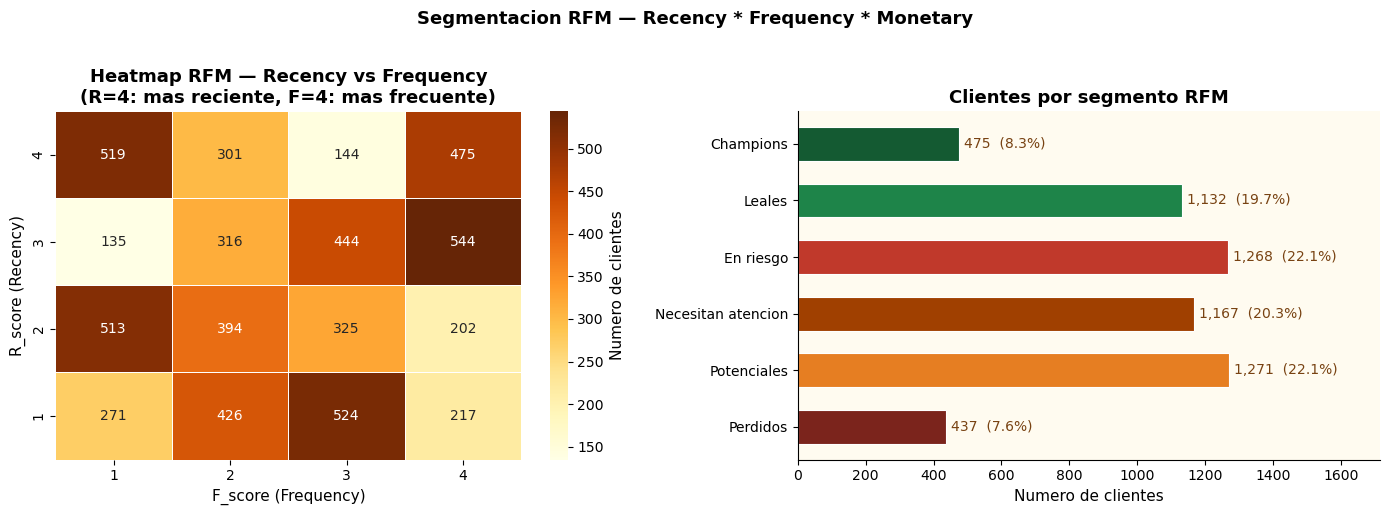

Guardado: graficos/cltv_07_rfm.png


In [14]:
COLORES_RFM = {
    'Champions':          '#145A32',
    'Leales':             '#1E8449',
    'Potenciales':        A3,
    'Necesitan atencion': A2,
    'En riesgo':          '#C0392B',
    'Perdidos':           '#7B241C',
}

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: heatmap R_score vs F_score ────────────────────────────────────
pivot_rf = df.groupby(['R_score','F_score']).size().unstack(fill_value=0)
pivot_rf = pivot_rf.reindex(index=[4,3,2,1], columns=[1,2,3,4], fill_value=0)
sns.heatmap(pivot_rf, ax=axes[0], cmap='YlOrBr', annot=True, fmt='d',
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Numero de clientes'})
axes[0].set_title('Heatmap RFM — Recency vs Frequency\n(R=4: mas reciente, F=4: mas frecuente)',
                  fontweight='bold')
axes[0].set_xlabel('F_score (Frequency)')
axes[0].set_ylabel('R_score (Recency)')

# ── Plot 2: clientes por segmento RFM ────────────────────────────────────
seg_order  = resumen_rfm.index.tolist()
n_seg_rfm  = resumen_rfm['n_clientes'].values
cols_rfm   = [COLORES_RFM.get(s, A3) for s in seg_order]

bars2 = axes[1].barh(seg_order[::-1], n_seg_rfm[::-1],
                     color=cols_rfm[::-1], edgecolor='white', linewidth=0.8, height=0.6)
for bar, n in zip(bars2, n_seg_rfm[::-1]):
    pct = n / len(df) * 100
    axes[1].text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
                 f'{n:,}  ({pct:.1f}%)', va='center', fontsize=10, color=A1)
axes[1].set_title('Clientes por segmento RFM', fontweight='bold')
axes[1].set_xlabel('Numero de clientes')
axes[1].set_xlim(0, n_seg_rfm.max() * 1.35)

fig.suptitle('Segmentacion RFM — Recency * Frequency * Monetary',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficos/cltv_07_rfm.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Guardado: graficos/cltv_07_rfm.png')

---
## 8. Visualizaciones CLTV — Top 20 y boxplot por segmento

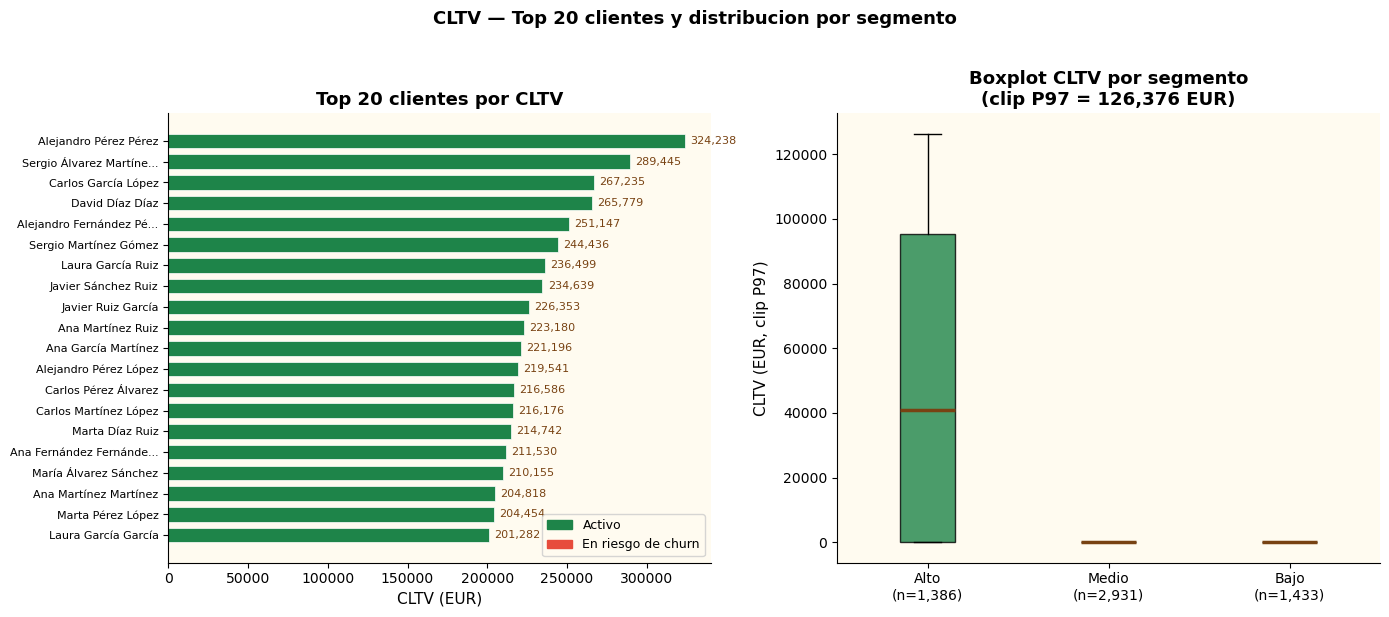

Guardado: graficos/cltv_08_top20.png


In [15]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Plot 1: top 20 clientes por CLTV ─────────────────────────────────────
top20 = df.nlargest(20, 'cltv')
cols_top20 = [A5 if ch else A6 for ch in top20['churn_proxy'].values]
bars1 = axes[0].barh(range(20), top20['cltv'].values[::-1],
                     color=cols_top20[::-1], edgecolor='white', linewidth=0.5, height=0.7)
axes[0].set_yticks(range(20))
nombres = top20['full_name'].values[::-1]
axes[0].set_yticklabels(
    [f'{str(n)[:22]}...' if len(str(n)) > 22 else str(n) for n in nombres],
    fontsize=8
)
for bar, val in zip(bars1, top20['cltv'].values[::-1]):
    axes[0].text(bar.get_width() + top20['cltv'].max() * 0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val:,.0f}', va='center', fontsize=8, color=A1)
axes[0].set_title('Top 20 clientes por CLTV', fontweight='bold')
axes[0].set_xlabel('CLTV (EUR)')
riesgo_p = mpatches.Patch(color=A5, label='En riesgo de churn')
activo_p = mpatches.Patch(color=A6, label='Activo')
axes[0].legend(handles=[activo_p, riesgo_p], fontsize=9)

# ── Plot 2: boxplot CLTV por segmento ────────────────────────────────────
clip_box = df['cltv'].quantile(0.97)
data_box = [df.loc[df['segmento_cltv'] == s, 'cltv'].clip(upper=clip_box).values
            for s in orden_seg]
bp = axes[1].boxplot(data_box, patch_artist=True, notch=False,
                     medianprops={'color': A1, 'linewidth': 2.5})
for patch, seg in zip(bp['boxes'], orden_seg):
    patch.set_facecolor(colores_seg[seg])
    patch.set_alpha(0.8)
n_seg_box = df['segmento_cltv'].value_counts()
axes[1].set_xticklabels(
    [f'{s}\n(n={n_seg_box.get(s,0):,})' for s in orden_seg], fontsize=10
)
axes[1].set_ylabel('CLTV (EUR, clip P97)')
axes[1].set_title(f'Boxplot CLTV por segmento\n(clip P97 = {clip_box:,.0f} EUR)',
                  fontweight='bold')

fig.suptitle('CLTV — Top 20 clientes y distribucion por segmento',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficos/cltv_08_top20.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Guardado: graficos/cltv_08_top20.png')

---
## 9. Visualizaciones RFM — Ingresos y distribucion espacial

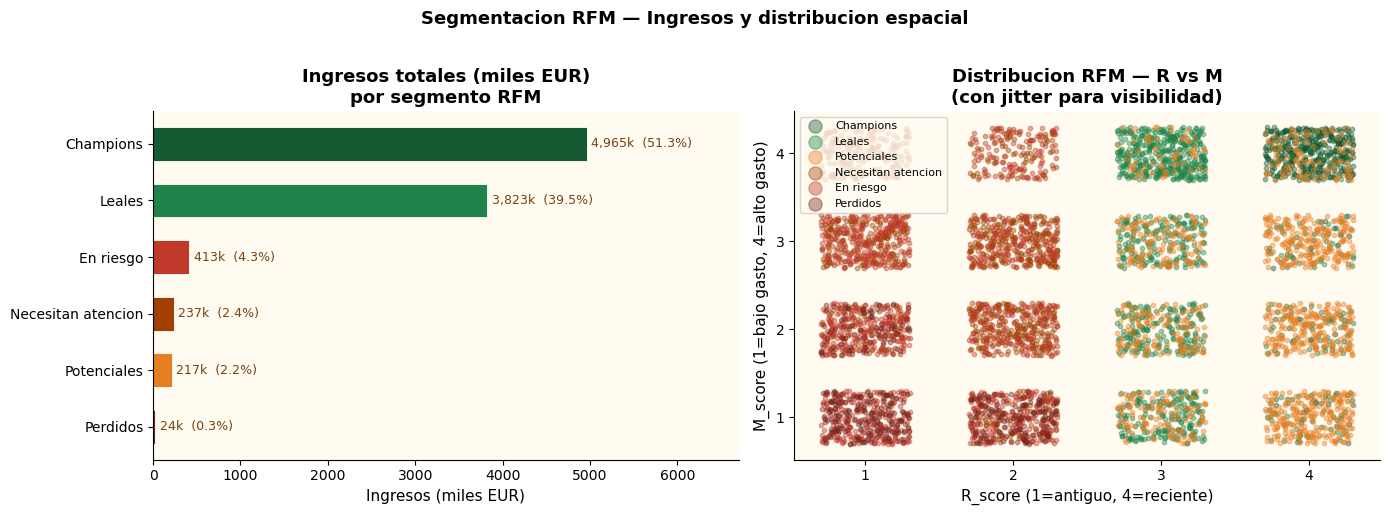

Guardado: graficos/cltv_09_rfm_resumen.png


In [16]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# ── Plot 1: ingresos por segmento RFM ─────────────────────────────────────
ing_rfm  = resumen_rfm['ingresos'].sort_values(ascending=True)
cols_rfm = [COLORES_RFM.get(s, A3) for s in ing_rfm.index]
bars1 = axes[0].barh(ing_rfm.index, ing_rfm.values / 1000,
                     color=cols_rfm, edgecolor='white', linewidth=0.6, height=0.6)
for bar, (seg, val) in zip(bars1, ing_rfm.items()):
    pct = val / total_ing * 100
    axes[0].text(bar.get_width() + ing_rfm.max() / 1000 * 0.01,
                 bar.get_y() + bar.get_height()/2,
                 f'{val/1000:,.0f}k  ({pct:.1f}%)', va='center', fontsize=9, color=A1)
axes[0].set_title('Ingresos totales (miles EUR)\npor segmento RFM', fontweight='bold')
axes[0].set_xlabel('Ingresos (miles EUR)')
axes[0].set_xlim(0, ing_rfm.max() / 1000 * 1.35)

# ── Plot 2: scatter R_score vs M_score coloreado por segmento ─────────────
jitter_r = df['R_score'] + np.random.uniform(-0.3, 0.3, len(df))
jitter_m = df['M_score'] + np.random.uniform(-0.3, 0.3, len(df))
for seg, color in COLORES_RFM.items():
    mask = df['segmento_rfm'] == seg
    if mask.sum() > 0:
        axes[1].scatter(jitter_r[mask], jitter_m[mask],
                        color=color, alpha=0.4, s=10, label=seg)
axes[1].set_xlabel('R_score (1=antiguo, 4=reciente)')
axes[1].set_ylabel('M_score (1=bajo gasto, 4=alto gasto)')
axes[1].set_title('Distribucion RFM — R vs M\n(con jitter para visibilidad)', fontweight='bold')
axes[1].legend(fontsize=8, markerscale=3, loc='upper left')
axes[1].set_xticks([1,2,3,4])
axes[1].set_yticks([1,2,3,4])

fig.suptitle('Segmentacion RFM — Ingresos y distribucion espacial',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('graficos/cltv_09_rfm_resumen.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Guardado: graficos/cltv_09_rfm_resumen.png')

---
## 10. Exportar `cltv_resultados.csv`

Exportamos todos los datos calculados en un unico CSV que sera la entrada de la
Fase 6 (PCA + Clustering). El fichero contiene 5.750 filas (una por cliente)
y todas las metricas necesarias para el analisis de segmentacion automatica.

In [17]:
# ── Validacion compacta de consistencia contra el DWH ─────────────────────

with engine.connect() as conn:
    ingresos_dwh = float(conn.execute(text('SELECT SUM(net_revenue) FROM dwh.fact_sales')).scalar())
    n_clientes_dwh = int(conn.execute(text('SELECT COUNT(DISTINCT customer_id) FROM dwh.fact_sales')).scalar())
    n_fact = int(conn.execute(text('SELECT COUNT(*) FROM dwh.fact_sales')).scalar())

ing_df = float(df['ingresos_t'].sum())
print(f'Ingresos en df (Python):     {ing_df:,.2f} EUR')
print(f'Ingresos en dwh.fact_sales:  {ingresos_dwh:,.2f} EUR')
print(f'Diferencia:                  {ing_df - ingresos_dwh:,.2f} EUR')
print(f'Filas en fact_sales:         {n_fact:,}')
print(f'Clientes en df extraido:     {len(df):,}')
print(f'Clientes distintos en fact:  {n_clientes_dwh:,}')

assert abs(ing_df - ingresos_dwh) < 1.0, 'Los ingresos agregados no cuadran con dwh.fact_sales'
assert len(df) == n_clientes_dwh, 'El DataFrame no contiene el mismo numero de clientes que fact_sales'
print('\nValidacion DWH OK.')

Ingresos en df (Python):     9,678,678.67 EUR
Ingresos en dwh.fact_sales:  9,678,678.67 EUR
Diferencia:                  0.00 EUR
Filas en fact_sales:         42,555
Clientes en df extraido:     5,750
Clientes distintos en fact:  5,750

Validacion DWH OK.


In [18]:
# Celda exploratoria retirada del flujo final.
print('Exploracion OLTP omitida en la version final del notebook.')

Exploracion OLTP omitida en la version final del notebook.


In [19]:
# Celda exploratoria retirada del flujo final.
print('Comparativa manual OLTP/DWH omitida en la version final del notebook.')

Comparativa manual OLTP/DWH omitida en la version final del notebook.


In [20]:
columnas_export = [
    'customer_id', 'full_name',
    'first_purchase_date', 'last_purchase_date', 'customer_age_days',
    # Componentes CLTV
    'ingresos_t', 'margen_total', 'margen_t',
    'num_ventas', 'num_lineas', 'r_t', 'frecuencia_t', 'ticket_medio',
    # CLTV y segmentacion
    'cltv', 'segmento_cltv',
    # Metrica 1: Churn Proxy
    'dias_sin_compra', 'churn_proxy',
    # Metrica 2: Tasa de devolucion
    'num_devoluciones', 'tasa_devolucion',
    # RFM
    'R_score', 'F_score', 'M_score', 'rfm_score', 'segmento_rfm',
]

df_export = df[columnas_export].copy()

# ── Verificaciones ANTES de redondear ─────────────────────────────────────
with engine.connect() as conn:
    ingresos_esperados = float(conn.execute(text('SELECT SUM(net_revenue) FROM dwh.fact_sales')).scalar())
    clientes_esperados = int(conn.execute(text('SELECT COUNT(DISTINCT customer_id) FROM dwh.fact_sales')).scalar())

assert len(df_export) == clientes_esperados, \
    f'Filas incorrectas: esperado {clientes_esperados:,}, obtenido {len(df_export):,}'

assert df_export['customer_id'].nunique() == clientes_esperados, \
    'customer_id no es único — hay clientes duplicados'

assert df_export['cltv'].isnull().sum() == 0, \
    'Hay NULLs en cltv'

assert (df_export['cltv'] < 0).sum() == 0, \
    f'Hay {(df_export["cltv"] < 0).sum()} clientes con CLTV negativo'

ing_csv = df_export['ingresos_t'].sum()
assert abs(ing_csv - ingresos_esperados) < 1.0, \
    f'Discrepancia en ingresos: CSV={ing_csv:,.2f} | Esperado={ingresos_esperados:,.2f}'

# ── Redondear y exportar DESPUÉS de verificar ─────────────────────────────
for col in ['ingresos_t','margen_total','margen_t','frecuencia_t','ticket_medio','cltv','r_t']:
    df_export[col] = df_export[col].round(4)

df_export.to_csv('cltv_resultados.csv', index=False)

print(f'Exportado: cltv_resultados.csv')
print(f'  Filas:    {len(df_export):,}')
print(f'  Columnas: {len(df_export.columns)}')
print(f'  Tamaño:  {os.path.getsize("cltv_resultados.csv") / 1024:.1f} KB')

print('\nVerificaciones:')
print(f'  ✓ {clientes_esperados:,} filas')
print(f'  ✓ customer_id único')
print(f'  ✓ Sin NULLs en cltv')
print(f'  ✓ Sin CLTV negativos')
print(f'  ✓ Ingresos totales: {ing_csv:,.2f} EUR (≈ {ingresos_esperados:,.2f} EUR)')
print('\nTodas las verificaciones OK.')

Exportado: cltv_resultados.csv
  Filas:    5,750
  Columnas: 24
  Tamaño:  794.7 KB

Verificaciones:
  ✓ 5,750 filas
  ✓ customer_id único
  ✓ Sin NULLs en cltv
  ✓ Sin CLTV negativos
  ✓ Ingresos totales: 9,678,678.67 EUR (≈ 9,678,678.67 EUR)

Todas las verificaciones OK.


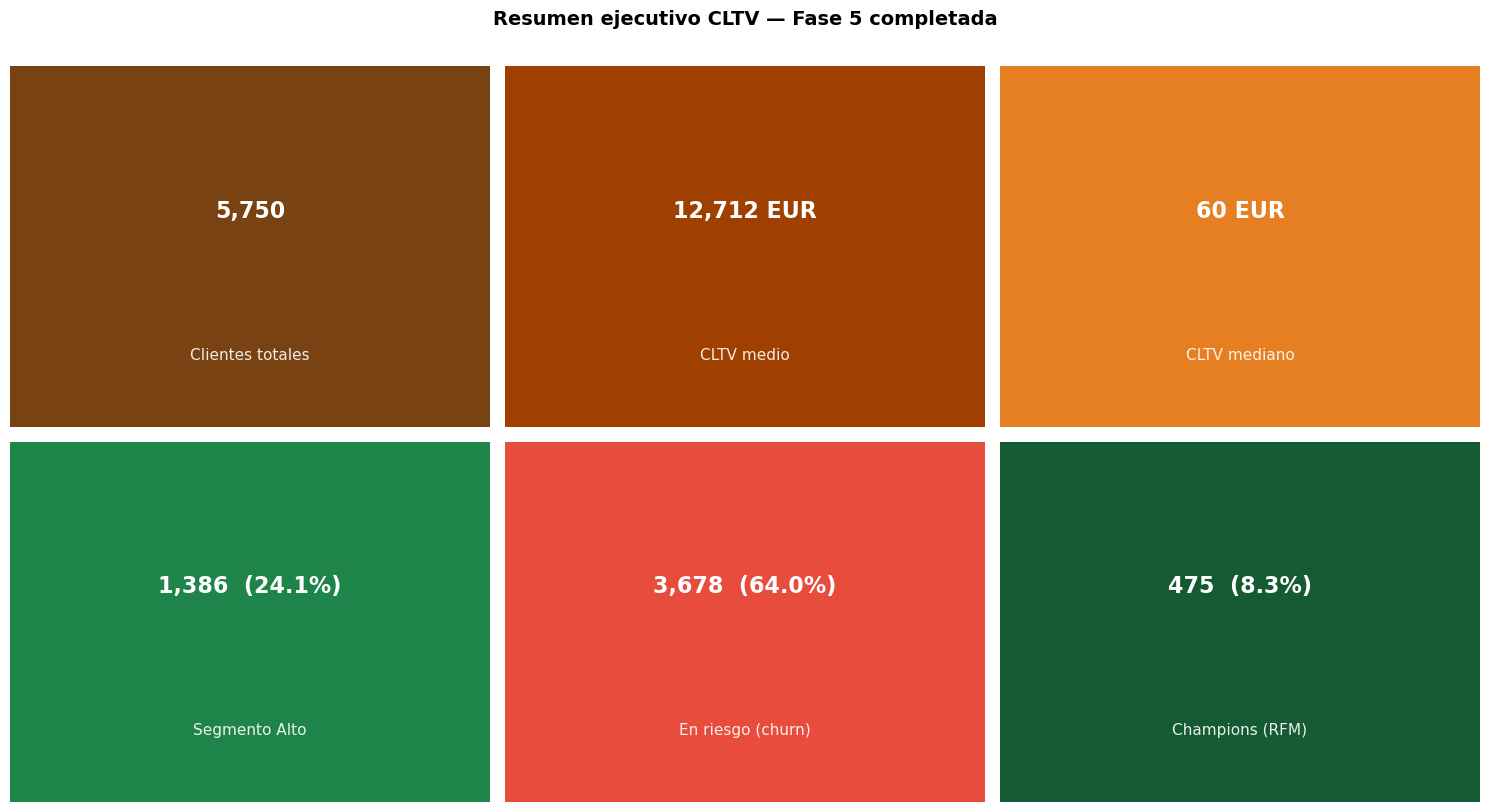

Guardado: graficos/cltv_10_kpis.png

Fase 5 completada. cltv_resultados.csv listo para la Fase 6 (PCA + Clustering).


In [21]:
# ── Dashboard KPIs ───────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

kpis = [
    ('Clientes totales',     f"{len(df):,}",                                             A1),
    ('CLTV medio',           f"{df['cltv'].mean():,.0f} EUR",                            A2),
    ('CLTV mediano',         f"{df['cltv'].median():,.0f} EUR",                          A3),
    ('Segmento Alto',        f"{(df['segmento_cltv']=='Alto').sum():,}  ({(df['segmento_cltv']=='Alto').mean()*100:.1f}%)", A6),
    ('En riesgo (churn)',    f"{df['churn_proxy'].sum():,}  ({df['churn_proxy'].mean()*100:.1f}%)", A5),
    ('Champions (RFM)',      f"{(df['segmento_rfm']=='Champions').sum():,}  ({(df['segmento_rfm']=='Champions').mean()*100:.1f}%)", '#145A32'),
]

for ax, (titulo, valor, color) in zip(axes.flat, kpis):
    ax.set_facecolor(color)
    ax.text(0.5, 0.60, valor, transform=ax.transAxes,
            ha='center', va='center', fontsize=16, fontweight='bold', color='white')
    ax.text(0.5, 0.20, titulo, transform=ax.transAxes,
            ha='center', va='center', fontsize=11, color='white', alpha=0.9)
    ax.set_xticks([])
    ax.set_yticks([])
    for spine in ax.spines.values():
        spine.set_visible(False)

fig.suptitle('Resumen ejecutivo CLTV — Fase 5 completada',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('graficos/cltv_10_kpis.png', dpi=120, bbox_inches='tight')
plt.show()
plt.close()
print('Guardado: graficos/cltv_10_kpis.png')
print('\nFase 5 completada. cltv_resultados.csv listo para la Fase 6 (PCA + Clustering).')

In [22]:
# ── Timestamp de ejecución ────────────────────────────────────────────────
import datetime
ts = datetime.datetime.now().strftime('%Y-%m-%d %H:%M:%S')
print('=' * 50)
print(f'Fase 5 completada: {ts}')
print(f'Clientes procesados:  {len(df_export):,}')
print(f'Ingresos totales:     {df_export["ingresos_t"].sum():,.2f} EUR')
print(f'CLTV medio:           {df_export["cltv"].mean():,.2f} EUR')
print(f'CLTV mediano:         {df_export["cltv"].median():,.2f} EUR')
print(f'Output: cltv_resultados.csv')
print('=' * 50)

Fase 5 completada: 2026-05-06 21:07:49
Clientes procesados:  5,750
Ingresos totales:     9,678,678.67 EUR
CLTV medio:           12,712.47 EUR
CLTV mediano:         59.96 EUR
Output: cltv_resultados.csv


---
## Resumen de la Fase 5

### Metricas calculadas

| Metrica | Descripcion | Uso en Fase 6 |
|---------|-------------|---------------|
| `cltv` | Formula del enunciado: `ingresos_t * margen_t * frecuencia_t * r_t` | Variable objetivo |
| `segmento_cltv` | Alto / Medio / Bajo (P25-P75) | Validacion de clusters |
| `ingresos_t` | Ingresos netos totales | Feature PCA |
| `margen_t` | Ratio de margen (0-1) | Feature PCA |
| `frecuencia_t` | Compras por mes | Feature PCA |
| `ticket_medio` | Gasto medio por compra | Feature PCA |
| `tasa_devolucion` | % lineas devueltas | Feature PCA |
| `dias_sin_compra` | Dias de inactividad | Feature PCA |
| `churn_proxy` | Flag de riesgo de abandono | Analisis de negocio |
| `R_score`, `F_score`, `M_score` | Scores RFM 1-4 | Validacion de clusters |
| `segmento_rfm` | Segmento CRM | Analisis de negocio |

### Fichero de salida

**`cltv_resultados.csv`** — 5.750 filas x 24 columnas  
Listo para la **Fase 6 — PCA + Clustering**.